In [10]:
import pandas as pd
import numpy as np

# Load reduced productivity dataset
df = pd.read_csv(
    "../data/processed/keyboard_reduced_productivity_dataset.csv"
)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (10000, 10)

Columns:
['participant', 'session', 'window_id', 'DU.key1.key1_median', 'DU.key1.key2_median', 'unique_key1_count', 'unique_transition_count', 'consecutive_key1_repetition_rate', 'backspace_rate', 'productivity_score']

First 5 rows:


,participant,session,window_id,DU.key1.key1_median,DU.key1.key2_median,unique_key1_count,unique_transition_count,consecutive_key1_repetition_rate,backspace_rate,productivity_score
0,p001,1,0,0.0950,0.3045,20,38,0.000000,0.00,64.127919
1,p001,1,1,0.0865,0.3335,18,41,0.020408,0.00,59.952122
2,p001,1,2,0.0945,0.3395,19,41,0.020408,0.00,59.827712
3,p001,1,3,0.0895,0.2665,19,41,0.061224,0.08,56.156184
4,p001,1,4,0.1030,0.2930,22,44,0.040816,0.00,71.066616


In [11]:
# Check window ordering within each participant-session

group_check = (
    df.sort_values(["participant", "session", "window_id"])
      .groupby(["participant", "session"])["window_id"]
      .apply(lambda x: np.all(np.diff(x.values) == 1))
)

print("Total participant-session groups:", len(group_check))
print("Groups with continuous window IDs:", group_check.sum())
print("Groups with gaps:", (~group_check).sum())

Total participant-session groups: 197
Groups with continuous window IDs: 197
Groups with gaps: 0


In [12]:
sequence_features = [
    "DU.key1.key1_median",
    "DU.key1.key2_median",
    "unique_key1_count",
    "unique_transition_count",
    "consecutive_key1_repetition_rate",
    "backspace_rate"
]

In [13]:
# Sequence configuration

sequence_features = [
    "DU.key1.key1_median",
    "DU.key1.key2_median",
    "unique_key1_count",
    "unique_transition_count",
    "consecutive_key1_repetition_rate",
    "backspace_rate"
]

sequence_length = 5

X_sequences = []
y_sequences = []
sequence_groups = []

# Ensure correct temporal ordering
df_sorted = df.sort_values(
    ["participant", "session", "window_id"]
).reset_index(drop=True)

# Create sequences within each participant-session
for (participant, session), group in df_sorted.groupby(
    ["participant", "session"]
):
    group = group.sort_values("window_id").reset_index(drop=True)

    features = group[sequence_features].values
    targets = group["productivity_score"].values

    for i in range(len(group) - sequence_length + 1):
        X_sequences.append(
            features[i:i + sequence_length]
        )

        # Target = productivity score of final window
        y_sequences.append(
            targets[i + sequence_length - 1]
        )

        sequence_groups.append(
            f"{participant}_session_{session}"
        )

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)
sequence_groups = np.array(sequence_groups)

print("X sequence shape:", X_sequences.shape)
print("y sequence shape:", y_sequences.shape)
print("Number of sequences:", len(X_sequences))
print("Number of groups:", len(np.unique(sequence_groups)))

X sequence shape: (9212, 5, 6)
y sequence shape: (9212,)
Number of sequences: 9212
Number of groups: 197


In [14]:
print("X sequence shape:", X_sequences.shape)
print("y sequence shape:", y_sequences.shape)
print("Number of sequences:", len(X_sequences))
print("Number of groups:", len(np.unique(sequence_groups)))

print("\nFirst sequence:")
print(X_sequences[0])

print("\nFirst target:")
print(y_sequences[0])

print("\nFirst sequence group:")
print(sequence_groups[0])

X sequence shape: (9212, 5, 6)
y sequence shape: (9212,)
Number of sequences: 9212
Number of groups: 197

First sequence:
[[9.50000000e-02 3.04500000e-01 2.00000000e+01 3.80000000e+01
  0.00000000e+00 0.00000000e+00]
 [8.65000000e-02 3.33500000e-01 1.80000000e+01 4.10000000e+01
  2.04081633e-02 0.00000000e+00]
 [9.45000000e-02 3.39500000e-01 1.90000000e+01 4.10000000e+01
  2.04081633e-02 0.00000000e+00]
 [8.95000000e-02 2.66500000e-01 1.90000000e+01 4.10000000e+01
  6.12244898e-02 8.00000000e-02]
 [1.03000000e-01 2.93000000e-01 2.20000000e+01 4.40000000e+01
  4.08163265e-02 0.00000000e+00]]

First target:
71.06661606661608

First sequence group:
p001_session_1


In [15]:
from sklearn.model_selection import GroupShuffleSplit

# Group-aware train/test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X_sequences,
        y_sequences,
        groups=sequence_groups
    )
)

X_train = X_sequences[train_idx]
X_test = X_sequences[test_idx]

y_train = y_sequences[train_idx]
y_test = y_sequences[test_idx]

groups_train = sequence_groups[train_idx]
groups_test = sequence_groups[test_idx]

print("Training sequences:", X_train.shape)
print("Testing sequences:", X_test.shape)

print("\nTraining groups:", len(np.unique(groups_train)))
print("Testing groups:", len(np.unique(groups_test)))

print(
    "\nGroup overlap:",
    len(
        set(groups_train).intersection(
            set(groups_test)
        )
    )
)

Training sequences: (7343, 5, 6)
Testing sequences: (1869, 5, 6)

Training groups: 157
Testing groups: 40

Group overlap: 0


In [16]:
from sklearn.preprocessing import StandardScaler

# Get dimensions
n_train, timesteps, n_features = X_train.shape
n_test = X_test.shape[0]

# Reshape training data to 2D
X_train_2d = X_train.reshape(
    -1,
    n_features
)

# Reshape testing data to 2D
X_test_2d = X_test.reshape(
    -1,
    n_features
)

# Fit scaler ONLY on training data
sequence_scaler = StandardScaler()

X_train_scaled_2d = sequence_scaler.fit_transform(
    X_train_2d
)

# Transform test data using the same scaler
X_test_scaled_2d = sequence_scaler.transform(
    X_test_2d
)

# Reshape back to 3D
X_train_scaled = X_train_scaled_2d.reshape(
    n_train,
    timesteps,
    n_features
)

X_test_scaled = X_test_scaled_2d.reshape(
    n_test,
    timesteps,
    n_features
)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nTraining feature means:")
print(X_train_scaled.reshape(-1, n_features).mean(axis=0))

print("\nTraining feature standard deviations:")
print(X_train_scaled.reshape(-1, n_features).std(axis=0))

Scaled training shape: (7343, 5, 6)
Scaled testing shape: (1869, 5, 6)

Training feature means:
[-7.74449520e-14 -2.14986834e-15 -6.32711914e-15 -2.42645192e-15
  1.05191332e-13  2.62813839e-13]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1.]


In [17]:
%pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [18]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.15.1


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM model
lstm_model = Sequential([
    LSTM(
        64,
        input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

# Compile model
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Display architecture
lstm_model.summary()

c:\Users\DELL\OneDrive\Desktop\EffiSense-Keyboard-Productivity\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

lstm_model = Sequential([
    Input(shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("LSTM training completed.")
print("Best validation loss:", min(history.history["val_loss"]))

Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1606.6505 - mae: 32.5955 - val_loss: 193.4037 - val_mae: 11.1520
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 158.1132 - mae: 10.0198 - val_loss: 76.7703 - val_mae: 6.9956
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 57.0001 - mae: 5.9871 - val_loss: 17.3529 - val_mae: 3.1228
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 29.9713 - mae: 4.3195 - val_loss: 8.9862 - val_mae: 2.1956
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 25.9150 - mae: 3.9676 - val_loss: 6.1611 - val_mae: 1.6711
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 23.2339 - mae: 3.7746 - val_loss: 5.6550 - val_mae: 1.6215
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 22.2468 - mae: 3.6865 - val_loss: 4.8536 - val_mae: 1.4106
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 22.1208 - mae: 3.6769 - val_loss: 4.8474 - val_mae: 1.4458
Epoch 9/100
184/184 ━━━━━━━━━━

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on the unseen test set
y_pred_lstm = lstm_model.predict(
    X_test_scaled,
    verbose=0
).flatten()

# Calculate regression metrics
lstm_mae = mean_absolute_error(y_test, y_pred_lstm)
lstm_mse = mean_squared_error(y_test, y_pred_lstm)
lstm_rmse = np.sqrt(lstm_mse)
lstm_r2 = r2_score(y_test, y_pred_lstm)

print("LSTM Test Results")
print("-----------------")
print(f"MAE  : {lstm_mae:.4f}")
print(f"MSE  : {lstm_mse:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"R²   : {lstm_r2:.4f}")

LSTM Test Results
-----------------
MAE  : 0.8087
MSE  : 1.4376
RMSE : 1.1990
R²   : 0.9934


In [23]:
lstm_results = pd.DataFrame([{
    "sequence_length": 5,
    "MAE": lstm_mae,
    "MSE": lstm_mse,
    "RMSE": lstm_rmse,
    "R2": lstm_r2
}])

lstm_results.to_csv(
    "../data/processed/lstm_results.csv",
    index=False
)

print("LSTM sequence-length 5 results saved successfully.")

LSTM sequence-length 5 results saved successfully.


In [24]:
# Create sequences with length 10

sequence_length = 10

X_sequences_10 = []
y_sequences_10 = []
sequence_groups_10 = []

df_sorted = df.sort_values(
    ["participant", "session", "window_id"]
).reset_index(drop=True)

for (participant, session), group in df_sorted.groupby(
    ["participant", "session"]
):
    group = group.sort_values("window_id").reset_index(drop=True)

    features = group[sequence_features].values
    targets = group["productivity_score"].values

    for i in range(len(group) - sequence_length + 1):
        X_sequences_10.append(
            features[i:i + sequence_length]
        )

        y_sequences_10.append(
            targets[i + sequence_length - 1]
        )

        sequence_groups_10.append(
            f"{participant}_session_{session}"
        )

X_sequences_10 = np.array(X_sequences_10)
y_sequences_10 = np.array(y_sequences_10)
sequence_groups_10 = np.array(sequence_groups_10)

print("X sequence shape:", X_sequences_10.shape)
print("y sequence shape:", y_sequences_10.shape)
print("Number of sequences:", len(X_sequences_10))
print("Number of groups:", len(np.unique(sequence_groups_10)))

X sequence shape: (8227, 10, 6)
y sequence shape: (8227,)
Number of sequences: 8227
Number of groups: 197


In [25]:
# Group-aware train/test split for sequence length 10

gss_10 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_10, test_idx_10 = next(
    gss_10.split(
        X_sequences_10,
        y_sequences_10,
        groups=sequence_groups_10
    )
)

X_train_10 = X_sequences_10[train_idx_10]
X_test_10 = X_sequences_10[test_idx_10]

y_train_10 = y_sequences_10[train_idx_10]
y_test_10 = y_sequences_10[test_idx_10]

groups_train_10 = sequence_groups_10[train_idx_10]
groups_test_10 = sequence_groups_10[test_idx_10]

print("Training sequences:", X_train_10.shape)
print("Testing sequences:", X_test_10.shape)

print("\nTraining groups:", len(np.unique(groups_train_10)))
print("Testing groups:", len(np.unique(groups_test_10)))

print(
    "\nGroup overlap:",
    len(
        set(groups_train_10).intersection(
            set(groups_test_10)
        )
    )
)

Training sequences: (6558, 10, 6)
Testing sequences: (1669, 10, 6)

Training groups: 157
Testing groups: 40

Group overlap: 0


In [26]:
from sklearn.preprocessing import StandardScaler

# Get dimensions
n_train_10, timesteps_10, n_features_10 = X_train_10.shape
n_test_10 = X_test_10.shape[0]

# Reshape 3D → 2D
X_train_10_2d = X_train_10.reshape(-1, n_features_10)
X_test_10_2d = X_test_10.reshape(-1, n_features_10)

# Fit ONLY on training data
sequence_scaler_10 = StandardScaler()

X_train_10_scaled_2d = sequence_scaler_10.fit_transform(
    X_train_10_2d
)

# Transform test using the training scaler
X_test_10_scaled_2d = sequence_scaler_10.transform(
    X_test_10_2d
)

# Reshape back to 3D
X_train_10_scaled = X_train_10_scaled_2d.reshape(
    n_train_10,
    timesteps_10,
    n_features_10
)

X_test_10_scaled = X_test_10_scaled_2d.reshape(
    n_test_10,
    timesteps_10,
    n_features_10
)

print("Scaled training shape:", X_train_10_scaled.shape)
print("Scaled testing shape:", X_test_10_scaled.shape)

print("\nTraining feature means:")
print(
    X_train_10_scaled
    .reshape(-1, n_features_10)
    .mean(axis=0)
)

print("\nTraining feature standard deviations:")
print(
    X_train_10_scaled
    .reshape(-1, n_features_10)
    .std(axis=0)
)

Scaled training shape: (6558, 10, 6)
Scaled testing shape: (1669, 10, 6)

Training feature means:
[-5.61700901e-15  8.44609192e-15  3.69178782e-15  7.51389734e-16
 -3.65582269e-13  2.61641740e-13]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1.]


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

lstm_model_10 = Sequential([
    Input(shape=(X_train_10_scaled.shape[1], X_train_10_scaled.shape[2])),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_10.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model_10.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_10 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_10 = lstm_model_10.fit(
    X_train_10_scaled,
    y_train_10,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_10],
    verbose=1
)

print("LSTM sequence length 10 training completed.")
print(
    "Best validation loss:",
    min(history_10.history["val_loss"])
)

Epoch 1/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1859.4897 - mae: 36.7750 - val_loss: 218.9661 - val_mae: 11.8926
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 191.5155 - mae: 11.1114 - val_loss: 129.6817 - val_mae: 9.2023
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 98.9331 - mae: 7.8993 - val_loss: 32.2020 - val_mae: 4.4469
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 36.3368 - mae: 4.7203 - val_loss: 9.9152 - val_mae: 2.3848
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 26.9919 - mae: 4.0509 - val_loss: 6.1352 - val_mae: 1.7229
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 23.2423 - mae: 3.7848 - val_loss: 5.4629 - val_mae: 1.5584
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 22.6983 - mae: 3.7112 - val_loss: 5.0135 - val_mae: 1.4506
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 21.4336 - mae: 3.6142 - val_loss: 5.7241 - val_mae: 1.6487
Epoch 9/100
164/164 ━━━━━━━━━

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on the test set
y_pred_10 = lstm_model_10.predict(X_test_10_scaled).flatten()

# Evaluation metrics
lstm_mae_10 = mean_absolute_error(y_test_10, y_pred_10)
lstm_mse_10 = mean_squared_error(y_test_10, y_pred_10)
lstm_rmse_10 = np.sqrt(lstm_mse_10)
lstm_r2_10 = r2_score(y_test_10, y_pred_10)

print("LSTM Sequence Length 10 Results")
print("--------------------------------")
print("MAE :", lstm_mae_10)
print("MSE :", lstm_mse_10)
print("RMSE:", lstm_rmse_10)
print("R²  :", lstm_r2_10)

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
LSTM Sequence Length 10 Results
--------------------------------
MAE : 0.7119842205612956
MSE : 1.1718190892954399
RMSE: 1.082505930374259
R²  : 0.9946845448704569


In [30]:
import pandas as pd

lstm_results = pd.DataFrame([
    {
        "sequence_length": 5,
        "MAE": 0.8087,
        "MSE": 1.4376,
        "RMSE": 1.1990,
        "R2": 0.9934
    },
    {
        "sequence_length": 10,
        "MAE": lstm_mae_10,
        "MSE": lstm_mse_10,
        "RMSE": lstm_rmse_10,
        "R2": lstm_r2_10
    }
])

lstm_results.to_csv(
    "../data/processed/lstm_results.csv",
    index=False
)

print(lstm_results)
print("\nSaved to: ../data/processed/lstm_results.csv")

   sequence_length       MAE       MSE      RMSE        R2
0                5  0.808700  1.437600  1.199000  0.993400
1               10  0.711984  1.171819  1.082506  0.994685

Saved to: ../data/processed/lstm_results.csv


In [32]:
import pandas as pd
import numpy as np

reduced_df = pd.read_csv(
    "../data/processed/keyboard_reduced_productivity_dataset.csv"
)

sequence_features = [
    "DU.key1.key1_median",
    "DU.key1.key2_median",
    "unique_key1_count",
    "unique_transition_count",
    "consecutive_key1_repetition_rate",
    "backspace_rate"
]

print("Dataset shape:", reduced_df.shape)
print("Features:", sequence_features)

Dataset shape: (10000, 10)
Features: ['DU.key1.key1_median', 'DU.key1.key2_median', 'unique_key1_count', 'unique_transition_count', 'consecutive_key1_repetition_rate', 'backspace_rate']


In [33]:
sequence_length_20 = 20

X_sequences_20 = []
y_sequences_20 = []
sequence_groups_20 = []

for (participant, session), group in reduced_df.groupby(
    ["participant", "session"]
):
    group = group.sort_values("window_id").reset_index(drop=True)

    for i in range(len(group) - sequence_length_20 + 1):
        sequence = group.loc[
            i:i + sequence_length_20 - 1,
            sequence_features
        ].values

        target = group.loc[
            i + sequence_length_20 - 1,
            "productivity_score"
        ]

        X_sequences_20.append(sequence)
        y_sequences_20.append(target)
        sequence_groups_20.append(
            f"{participant}_{session}"
        )

X_sequences_20 = np.array(X_sequences_20)
y_sequences_20 = np.array(y_sequences_20)
sequence_groups_20 = np.array(sequence_groups_20)

print("X shape:", X_sequences_20.shape)
print("y shape:", y_sequences_20.shape)
print("Number of groups:", len(np.unique(sequence_groups_20)))

X shape: (6257, 20, 6)
y shape: (6257,)
Number of groups: 197


In [34]:
from sklearn.model_selection import GroupShuffleSplit

gss_20 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_20, test_idx_20 = next(
    gss_20.split(
        X_sequences_20,
        y_sequences_20,
        groups=sequence_groups_20
    )
)

X_train_20 = X_sequences_20[train_idx_20]
X_test_20 = X_sequences_20[test_idx_20]

y_train_20 = y_sequences_20[train_idx_20]
y_test_20 = y_sequences_20[test_idx_20]

groups_train_20 = sequence_groups_20[train_idx_20]
groups_test_20 = sequence_groups_20[test_idx_20]

print("Training sequences:", X_train_20.shape)
print("Test sequences:", X_test_20.shape)

print(
    "Training groups:",
    len(np.unique(groups_train_20))
)

print(
    "Test groups:",
    len(np.unique(groups_test_20))
)

print(
    "Group overlap:",
    len(
        set(groups_train_20).intersection(
            set(groups_test_20)
        )
    )
)

Training sequences: (4988, 20, 6)
Test sequences: (1269, 20, 6)
Training groups: 157
Test groups: 40
Group overlap: 0


In [35]:
from sklearn.preprocessing import StandardScaler

scaler_20 = StandardScaler()

# Reshape training sequences to 2D
X_train_20_reshaped = X_train_20.reshape(
    -1,
    X_train_20.shape[-1]
)

# Fit scaler ONLY on training data
scaler_20.fit(X_train_20_reshaped)

# Scale training data
X_train_20_scaled = scaler_20.transform(
    X_train_20_reshaped
).reshape(X_train_20.shape)

# Scale test data using the same scaler
X_test_20_scaled = scaler_20.transform(
    X_test_20.reshape(-1, X_test_20.shape[-1])
).reshape(X_test_20.shape)

print("Scaled training shape:", X_train_20_scaled.shape)
print("Scaled test shape:", X_test_20_scaled.shape)

print(
    "Training mean:",
    X_train_20_scaled.mean(axis=(0, 1))
)

print(
    "Training std:",
    X_train_20_scaled.std(axis=(0, 1))
)

Scaled training shape: (4988, 20, 6)
Scaled test shape: (1269, 20, 6)
Training mean: [ 2.53985719e-13 -1.10906927e-13 -1.90745352e-15  6.59184905e-16
 -7.94634126e-13 -3.85944974e-13]
Training std: [1. 1. 1. 1. 1. 1.]


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

lstm_model_20 = Sequential([
    Input(shape=(
        X_train_20_scaled.shape[1],
        X_train_20_scaled.shape[2]
    )),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_20.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model_20.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_20 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_20 = lstm_model_20.fit(
    X_train_20_scaled,
    y_train_20,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_20],
    verbose=1
)

print("LSTM sequence length 20 training completed.")
print(
    "Best validation loss:",
    min(history_20.history["val_loss"])
)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 1907.2076 - mae: 37.9935 - val_loss: 257.4338 - val_mae: 13.2107
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 233.1981 - mae: 12.2953 - val_loss: 222.2018 - val_mae: 12.0647
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 197.9280 - mae: 11.3172 - val_loss: 149.4195 - val_mae: 9.9440
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 107.6586 - mae: 8.1939 - val_loss: 43.7680 - val_mae: 5.2004
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 40.6251 - mae: 4.9669 - val_loss: 13.5670 - val_mae: 2.6927
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 24.5026 - mae: 3.8808 - val_loss: 8.1140 - val_mae: 1.8329
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 21.9891 - mae: 3.5960 - val_loss: 6.7602 - val_mae: 1.6904
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 21.3188 - mae: 3.5917 - val_loss: 6.5052 - val_mae: 1.7100
Epoch 9/100
125/125

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on the test set
y_pred_20 = lstm_model_20.predict(X_test_20_scaled).flatten()

# Evaluation metrics
lstm_mae_20 = mean_absolute_error(y_test_20, y_pred_20)
lstm_mse_20 = mean_squared_error(y_test_20, y_pred_20)
lstm_rmse_20 = np.sqrt(lstm_mse_20)
lstm_r2_20 = r2_score(y_test_20, y_pred_20)

print("LSTM Sequence Length 20 Results")
print("--------------------------------")
print("MAE :", lstm_mae_20)
print("MSE :", lstm_mse_20)
print("RMSE:", lstm_rmse_20)
print("R²  :", lstm_r2_20)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
LSTM Sequence Length 20 Results
--------------------------------
MAE : 1.0586780466881078
MSE : 2.73373609374281
RMSE: 1.6534013710357234
R²  : 0.9878294863978471


In [39]:
import pandas as pd

lstm_results = pd.DataFrame([
    {
        "sequence_length": 5,
        "MAE": 0.8087,
        "MSE": 1.4376,
        "RMSE": 1.1990,
        "R2": 0.9934
    },
    {
        "sequence_length": 10,
        "MAE": 0.7119842205612956,
        "MSE": 1.1718190892954399,
        "RMSE": 1.082505930374259,
        "R2": 0.9946845448704569
    },
    {
        "sequence_length": 20,
        "MAE": lstm_mae_20,
        "MSE": lstm_mse_20,
        "RMSE": lstm_rmse_20,
        "R2": lstm_r2_20
    }
])

lstm_results.to_csv(
    "../data/processed/lstm_results.csv",
    index=False
)

print(lstm_results)
print("\nSaved successfully.")

   sequence_length       MAE       MSE      RMSE        R2
0                5  0.808700  1.437600  1.199000  0.993400
1               10  0.711984  1.171819  1.082506  0.994685
2               20  1.058678  2.733736  1.653401  0.987829

Saved successfully.


In [40]:
sequence_length_30 = 30

X_sequences_30 = []
y_sequences_30 = []
sequence_groups_30 = []

for (participant, session), group in reduced_df.groupby(
    ["participant", "session"]
):
    group = group.sort_values("window_id").reset_index(drop=True)

    for i in range(len(group) - sequence_length_30 + 1):
        sequence = group.loc[
            i:i + sequence_length_30 - 1,
            sequence_features
        ].values

        target = group.loc[
            i + sequence_length_30 - 1,
            "productivity_score"
        ]

        X_sequences_30.append(sequence)
        y_sequences_30.append(target)
        sequence_groups_30.append(
            f"{participant}_{session}"
        )

X_sequences_30 = np.array(X_sequences_30)
y_sequences_30 = np.array(y_sequences_30)
sequence_groups_30 = np.array(sequence_groups_30)

print("X shape:", X_sequences_30.shape)
print("y shape:", y_sequences_30.shape)
print(
    "Number of groups:",
    len(np.unique(sequence_groups_30))
)

X shape: (4287, 30, 6)
y shape: (4287,)
Number of groups: 197


In [41]:
from sklearn.model_selection import GroupShuffleSplit

gss_30 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_30, test_idx_30 = next(
    gss_30.split(
        X_sequences_30,
        y_sequences_30,
        groups=sequence_groups_30
    )
)

X_train_30 = X_sequences_30[train_idx_30]
X_test_30 = X_sequences_30[test_idx_30]

y_train_30 = y_sequences_30[train_idx_30]
y_test_30 = y_sequences_30[test_idx_30]

groups_train_30 = sequence_groups_30[train_idx_30]
groups_test_30 = sequence_groups_30[test_idx_30]

print("Training sequences:", X_train_30.shape)
print("Test sequences:", X_test_30.shape)

print(
    "Training groups:",
    len(np.unique(groups_train_30))
)

print(
    "Test groups:",
    len(np.unique(groups_test_30))
)

print(
    "Group overlap:",
    len(
        set(groups_train_30).intersection(
            set(groups_test_30)
        )
    )
)

Training sequences: (3418, 30, 6)
Test sequences: (869, 30, 6)
Training groups: 157
Test groups: 40
Group overlap: 0


In [42]:
from sklearn.preprocessing import StandardScaler

scaler_30 = StandardScaler()

# Reshape training sequences to 2D
X_train_30_reshaped = X_train_30.reshape(
    -1,
    X_train_30.shape[-1]
)

# Fit ONLY on training data
scaler_30.fit(X_train_30_reshaped)

# Transform training data
X_train_30_scaled = scaler_30.transform(
    X_train_30_reshaped
).reshape(X_train_30.shape)

# Transform test data using the same scaler
X_test_30_scaled = scaler_30.transform(
    X_test_30.reshape(-1, X_test_30.shape[-1])
).reshape(X_test_30.shape)

print("Scaled training shape:", X_train_30_scaled.shape)
print("Scaled test shape:", X_test_30_scaled.shape)

print(
    "Training mean:",
    X_train_30_scaled.mean(axis=(0, 1))
)

print(
    "Training std:",
    X_train_30_scaled.std(axis=(0, 1))
)

Scaled training shape: (3418, 30, 6)
Scaled test shape: (869, 30, 6)
Training mean: [ 3.86877843e-13 -1.62998384e-13  3.86103931e-15 -3.24503227e-15
 -8.24266793e-13 -4.35061906e-13]
Training std: [1. 1. 1. 1. 1. 1.]


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

lstm_model_30 = Sequential([
    Input(shape=(
        X_train_30_scaled.shape[1],
        X_train_30_scaled.shape[2]
    )),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model_30.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model_30.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_30 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_30 = lstm_model_30.fit(
    X_train_30_scaled,
    y_train_30,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_30],
    verbose=1
)

print("LSTM sequence length 30 training completed.")
print(
    "Best validation loss:",
    min(history_30.history["val_loss"])
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 3171.4231 - mae: 53.9712 - val_loss: 2147.3240 - val_mae: 43.6329
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1192.9539 - mae: 30.5398 - val_loss: 502.4231 - val_mae: 18.7267
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 311.4131 - mae: 14.4513 - val_loss: 231.8101 - val_mae: 12.5379
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 224.7320 - mae: 12.0773 - val_loss: 211.4214 - val_mae: 11.8631
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 208.8937 - mae: 11.5991 - val_loss: 177.8952 - val_mae: 10.8409
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 187.5446 - mae: 11.0584 - val_loss: 148.4327 - val_mae: 9.8713
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 158.2244 - mae: 10.0978 - val_loss: 117.5463 - val_mae: 8.6626
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 128.8311 - mae: 9.1344 - val_loss: 91.7486 - val_mae: 7.7656
Epoch 9/10

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on the test set
y_pred_30 = lstm_model_30.predict(X_test_30_scaled).flatten()

# Evaluation metrics
lstm_mae_30 = mean_absolute_error(y_test_30, y_pred_30)
lstm_mse_30 = mean_squared_error(y_test_30, y_pred_30)
lstm_rmse_30 = np.sqrt(lstm_mse_30)
lstm_r2_30 = r2_score(y_test_30, y_pred_30)

print("LSTM Sequence Length 30 Results")
print("--------------------------------")
print("MAE :", lstm_mae_30)
print("MSE :", lstm_mse_30)
print("RMSE:", lstm_rmse_30)
print("R²  :", lstm_r2_30)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
LSTM Sequence Length 30 Results
--------------------------------
MAE : 1.3051663280644832
MSE : 4.578792496594349
RMSE: 2.1398113226624327
R²  : 0.9800257506496455


In [46]:
import pandas as pd

lstm_results = pd.DataFrame([
    {
        "sequence_length": 5,
        "MAE": 0.8087,
        "MSE": 1.4376,
        "RMSE": 1.1990,
        "R2": 0.9934
    },
    {
        "sequence_length": 10,
        "MAE": 0.7119842205612956,
        "MSE": 1.1718190892954399,
        "RMSE": 1.082505930374259,
        "R2": 0.9946845448704569
    },
    {
        "sequence_length": 20,
        "MAE": 1.0586780466881078,
        "MSE": 2.73373609374281,
        "RMSE": 1.6534013710357234,
        "R2": 0.9878294863978471
    },
    {
        "sequence_length": 30,
        "MAE": lstm_mae_30,
        "MSE": lstm_mse_30,
        "RMSE": lstm_rmse_30,
        "R2": lstm_r2_30
    }
])

lstm_results.to_csv(
    "../data/processed/lstm_results.csv",
    index=False
)

print(lstm_results)
print("\nSaved to: ../data/processed/lstm_results.csv")

   sequence_length       MAE       MSE      RMSE        R2
0                5  0.808700  1.437600  1.199000  0.993400
1               10  0.711984  1.171819  1.082506  0.994685
2               20  1.058678  2.733736  1.653401  0.987829
3               30  1.305166  4.578792  2.139811  0.980026

Saved to: ../data/processed/lstm_results.csv


In [47]:
lstm_results_check = pd.read_csv(
    "../data/processed/lstm_results.csv"
)

print(lstm_results_check)
print("\nShape:", lstm_results_check.shape)
print("\nFile saved correctly.")

   sequence_length       MAE       MSE      RMSE        R2
0                5  0.808700  1.437600  1.199000  0.993400
1               10  0.711984  1.171819  1.082506  0.994685
2               20  1.058678  2.733736  1.653401  0.987829
3               30  1.305166  4.578792  2.139811  0.980026

Shape: (4, 5)

File saved correctly.


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout

gru_model_10 = Sequential([
    Input(shape=(
        X_train_10_scaled.shape[1],
        X_train_10_scaled.shape[2]
    )),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model_10.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model_10.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,937 (62.25 KB)

 Trainable params: 15,937 (62.25 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_gru_10 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_gru_10 = gru_model_10.fit(
    X_train_10_scaled,
    y_train_10,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_gru_10],
    verbose=1
)

print("GRU sequence length 10 training completed.")
print(
    "Best validation loss:",
    min(history_gru_10.history["val_loss"])
)

Epoch 1/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1542.8271 - mae: 32.1771 - val_loss: 224.1433 - val_mae: 12.0632
Epoch 2/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 215.0769 - mae: 11.8232 - val_loss: 160.4653 - val_mae: 10.1962
Epoch 3/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 113.0086 - mae: 8.3202 - val_loss: 48.7402 - val_mae: 5.3491
Epoch 4/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 38.6258 - mae: 4.7795 - val_loss: 9.6604 - val_mae: 2.1148
Epoch 5/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 26.6721 - mae: 4.0135 - val_loss: 7.6041 - val_mae: 1.9705
Epoch 6/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 25.6638 - mae: 3.9182 - val_loss: 8.3522 - val_mae: 1.9218
Epoch 7/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 24.6878 - mae: 3.8655 - val_loss: 5.5683 - val_mae: 1.5519
Epoch 8/100
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 24.5971 - mae: 3.8806 - val_loss: 5.7577 - val_mae: 1.5791
Epoch 9/100
164/164 ━━━━━━━

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on test data
y_pred_gru_10 = gru_model_10.predict(X_test_10_scaled).flatten()

# Metrics
gru_mae_10 = mean_absolute_error(y_test_10, y_pred_gru_10)
gru_mse_10 = mean_squared_error(y_test_10, y_pred_gru_10)
gru_rmse_10 = np.sqrt(gru_mse_10)
gru_r2_10 = r2_score(y_test_10, y_pred_gru_10)

print("GRU Sequence Length 10 Test Results")
print("MAE :", gru_mae_10)
print("MSE :", gru_mse_10)
print("RMSE:", gru_rmse_10)
print("R²  :", gru_r2_10)

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
GRU Sequence Length 10 Test Results
MAE : 1.099531333600723
MSE : 2.7584196651247876
RMSE: 1.6608490795748985
R²  : 0.9874876112768942


In [52]:
print("X_train_5:", "X_train_5" in globals())
print("X_test_5:", "X_test_5" in globals())
print("X_train_5_scaled:", "X_train_5_scaled" in globals())
print("X_test_5_scaled:", "X_test_5_scaled" in globals())
print("y_train_5:", "y_train_5" in globals())
print("y_test_5:", "y_test_5" in globals())

X_train_5: False
X_test_5: False
X_train_5_scaled: False
X_test_5_scaled: False
y_train_5: False
y_test_5: False


In [54]:
selected_features = [
    "DU.key1.key1_median",
    "DU.key1.key2_median",
    "unique_key1_count",
    "unique_transition_count",
    "consecutive_key1_repetition_rate",
    "backspace_rate"
]

print("Selected features:")
for feature in selected_features:
    print(feature)

Selected features:
DU.key1.key1_median
DU.key1.key2_median
unique_key1_count
unique_transition_count
consecutive_key1_repetition_rate
backspace_rate


In [55]:
sequence_length = 5

X_5 = []
y_5 = []
groups_5 = []

for (participant, session), group in reduced_df.groupby(
    ["participant", "session"]
):
    group = group.sort_values("window_id").reset_index(drop=True)

    feature_values = group[selected_features].values
    target_values = group["productivity_score"].values

    for i in range(len(group) - sequence_length + 1):
        X_5.append(
            feature_values[i:i + sequence_length]
        )
        y_5.append(
            target_values[i + sequence_length - 1]
        )
        groups_5.append(
            f"{participant}_{session}"
        )

X_5 = np.array(X_5)
y_5 = np.array(y_5)
groups_5 = np.array(groups_5)

print("X shape:", X_5.shape)
print("y shape:", y_5.shape)
print("Number of groups:", len(np.unique(groups_5)))

X shape: (9212, 5, 6)
y shape: (9212,)
Number of groups: 197


In [56]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# Group-based train/test split
gss_5 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_5, test_idx_5 = next(
    gss_5.split(X_5, y_5, groups=groups_5)
)

X_train_5 = X_5[train_idx_5]
X_test_5 = X_5[test_idx_5]

y_train_5 = y_5[train_idx_5]
y_test_5 = y_5[test_idx_5]

groups_train_5 = groups_5[train_idx_5]
groups_test_5 = groups_5[test_idx_5]

print("Train shape:", X_train_5.shape)
print("Test shape:", X_test_5.shape)
print("Train groups:", len(np.unique(groups_train_5)))
print("Test groups:", len(np.unique(groups_test_5)))
print(
    "Group overlap:",
    len(set(groups_train_5) & set(groups_test_5))
)

# Scale using training data only
scaler_5 = StandardScaler()

X_train_5_2d = X_train_5.reshape(
    -1, X_train_5.shape[-1]
)

X_test_5_2d = X_test_5.reshape(
    -1, X_test_5.shape[-1]
)

scaler_5.fit(X_train_5_2d)

X_train_5_scaled = scaler_5.transform(
    X_train_5_2d
).reshape(X_train_5.shape)

X_test_5_scaled = scaler_5.transform(
    X_test_5_2d
).reshape(X_test_5.shape)

print("Scaled train shape:", X_train_5_scaled.shape)
print("Scaled test shape:", X_test_5_scaled.shape)

Train shape: (7343, 5, 6)
Test shape: (1869, 5, 6)
Train groups: 157
Test groups: 40
Group overlap: 0
Scaled train shape: (7343, 5, 6)
Scaled test shape: (1869, 5, 6)


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

gru_model_5 = Sequential([
    Input(shape=(
        X_train_5_scaled.shape[1],
        X_train_5_scaled.shape[2]
    )),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model_5.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stopping_gru_5 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_gru_5 = gru_model_5.fit(
    X_train_5_scaled,
    y_train_5,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_gru_5],
    verbose=1
)

print("GRU sequence length 5 training completed.")
print(
    "Best validation loss:",
    min(history_gru_5.history["val_loss"])
)

Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 1465.0497 - mae: 30.2382 - val_loss: 202.4907 - val_mae: 11.3749
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 154.0817 - mae: 9.8536 - val_loss: 75.6064 - val_mae: 6.7502
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 54.3093 - mae: 5.6775 - val_loss: 13.8862 - val_mae: 2.6750
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 30.0851 - mae: 4.2844 - val_loss: 8.2402 - val_mae: 1.9579
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 25.6939 - mae: 3.9582 - val_loss: 6.3767 - val_mae: 1.7403
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 24.0019 - mae: 3.8224 - val_loss: 5.5350 - val_mae: 1.5942
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 23.2859 - mae: 3.7913 - val_loss: 4.9269 - val_mae: 1.4558
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 22.6195 - mae: 3.7029 - val_loss: 4.5006 - val_mae: 1.4699
Epoch 9/100
184/184 ━━━━━━━

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_gru_5 = gru_model_5.predict(X_test_5_scaled).flatten()

gru_mae_5 = mean_absolute_error(y_test_5, y_pred_gru_5)
gru_mse_5 = mean_squared_error(y_test_5, y_pred_gru_5)
gru_rmse_5 = np.sqrt(gru_mse_5)
gru_r2_5 = r2_score(y_test_5, y_pred_gru_5)

print("GRU Sequence Length 5 Test Results")
print("MAE :", gru_mae_5)
print("MSE :", gru_mse_5)
print("RMSE:", gru_rmse_5)
print("R²  :", gru_r2_5)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
GRU Sequence Length 5 Test Results
MAE : 0.8543082388232902
MSE : 2.0419929828036687
RMSE: 1.4289831989228106
R²  : 0.990619722389419


In [59]:
sequence_length = 20

X_20 = []
y_20 = []
groups_20 = []

for (participant, session), group in reduced_df.groupby(
    ["participant", "session"]
):
    group = group.sort_values("window_id").reset_index(drop=True)

    feature_values = group[selected_features].values
    target_values = group["productivity_score"].values

    for i in range(len(group) - sequence_length + 1):
        X_20.append(
            feature_values[i:i + sequence_length]
        )
        y_20.append(
            target_values[i + sequence_length - 1]
        )
        groups_20.append(
            f"{participant}_{session}"
        )

X_20 = np.array(X_20)
y_20 = np.array(y_20)
groups_20 = np.array(groups_20)

print("X shape:", X_20.shape)
print("y shape:", y_20.shape)
print("Number of groups:", len(np.unique(groups_20)))

X shape: (6257, 20, 6)
y shape: (6257,)
Number of groups: 197


In [60]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

gss_20 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_20, test_idx_20 = next(
    gss_20.split(X_20, y_20, groups=groups_20)
)

X_train_20 = X_20[train_idx_20]
X_test_20 = X_20[test_idx_20]

y_train_20 = y_20[train_idx_20]
y_test_20 = y_20[test_idx_20]

groups_train_20 = groups_20[train_idx_20]
groups_test_20 = groups_20[test_idx_20]

print("Train shape:", X_train_20.shape)
print("Test shape:", X_test_20.shape)
print("Train groups:", len(np.unique(groups_train_20)))
print("Test groups:", len(np.unique(groups_test_20)))
print(
    "Group overlap:",
    len(set(groups_train_20) & set(groups_test_20))
)

# Scale using training data only
scaler_20 = StandardScaler()

X_train_20_2d = X_train_20.reshape(
    -1, X_train_20.shape[-1]
)

X_test_20_2d = X_test_20.reshape(
    -1, X_test_20.shape[-1]
)

scaler_20.fit(X_train_20_2d)

X_train_20_scaled = scaler_20.transform(
    X_train_20_2d
).reshape(X_train_20.shape)

X_test_20_scaled = scaler_20.transform(
    X_test_20_2d
).reshape(X_test_20.shape)

print("Scaled train shape:", X_train_20_scaled.shape)
print("Scaled test shape:", X_test_20_scaled.shape)

Train shape: (4988, 20, 6)
Test shape: (1269, 20, 6)
Train groups: 157
Test groups: 40
Group overlap: 0
Scaled train shape: (4988, 20, 6)
Scaled test shape: (1269, 20, 6)


In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

gru_model_20 = Sequential([
    Input(shape=(
        X_train_20_scaled.shape[1],
        X_train_20_scaled.shape[2]
    )),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model_20.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stopping_gru_20 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_gru_20 = gru_model_20.fit(
    X_train_20_scaled,
    y_train_20,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_gru_20],
    verbose=1
)

print("GRU sequence length 20 training completed.")
print(
    "Best validation loss:",
    min(history_gru_20.history["val_loss"])
)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 2263.8765 - mae: 43.0240 - val_loss: 383.0757 - val_mae: 16.4314
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 232.9451 - mae: 12.3594 - val_loss: 188.4353 - val_mae: 11.0870
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 129.9419 - mae: 8.9368 - val_loss: 49.0892 - val_mae: 5.3696
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 40.9517 - mae: 4.9417 - val_loss: 14.1090 - val_mae: 2.6329
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 29.4549 - mae: 4.2021 - val_loss: 9.9707 - val_mae: 2.0765
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 26.5023 - mae: 4.0210 - val_loss: 10.6656 - val_mae: 2.2461
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 25.4667 - mae: 3.9668 - val_loss: 7.6949 - val_mae: 1.8331
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 24.9139 - mae: 3.8920 - val_loss: 6.2010 - val_mae: 1.6922
Epoch 9/100
125/1

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_gru_20 = gru_model_20.predict(X_test_20_scaled).flatten()

gru_mae_20 = mean_absolute_error(y_test_20, y_pred_gru_20)
gru_mse_20 = mean_squared_error(y_test_20, y_pred_gru_20)
gru_rmse_20 = np.sqrt(gru_mse_20)
gru_r2_20 = r2_score(y_test_20, y_pred_gru_20)

print("GRU Sequence Length 20 Test Results")
print("MAE :", gru_mae_20)
print("MSE :", gru_mse_20)
print("RMSE:", gru_rmse_20)
print("R²  :", gru_r2_20)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
GRU Sequence Length 20 Test Results
MAE : 0.9384614950767128
MSE : 2.6161081480607806
RMSE: 1.6174387617652732
R²  : 0.9883531625918268


In [63]:
sequence_length = 30

X_30 = []
y_30 = []
groups_30 = []

for (participant, session), group in reduced_df.groupby(
    ["participant", "session"]
):
    group = group.sort_values("window_id").reset_index(drop=True)

    feature_values = group[selected_features].values
    target_values = group["productivity_score"].values

    for i in range(len(group) - sequence_length + 1):
        X_30.append(
            feature_values[i:i + sequence_length]
        )
        y_30.append(
            target_values[i + sequence_length - 1]
        )
        groups_30.append(
            f"{participant}_{session}"
        )

X_30 = np.array(X_30)
y_30 = np.array(y_30)
groups_30 = np.array(groups_30)

print("X shape:", X_30.shape)
print("y shape:", y_30.shape)
print("Number of groups:", len(np.unique(groups_30)))

X shape: (4287, 30, 6)
y shape: (4287,)
Number of groups: 197


In [64]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

gss_30 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_30, test_idx_30 = next(
    gss_30.split(X_30, y_30, groups=groups_30)
)

X_train_30 = X_30[train_idx_30]
X_test_30 = X_30[test_idx_30]

y_train_30 = y_30[train_idx_30]
y_test_30 = y_30[test_idx_30]

groups_train_30 = groups_30[train_idx_30]
groups_test_30 = groups_30[test_idx_30]

print("Train shape:", X_train_30.shape)
print("Test shape:", X_test_30.shape)
print("Train groups:", len(np.unique(groups_train_30)))
print("Test groups:", len(np.unique(groups_test_30)))
print(
    "Group overlap:",
    len(set(groups_train_30) & set(groups_test_30))
)

# Scale using training data only
scaler_30 = StandardScaler()

X_train_30_2d = X_train_30.reshape(
    -1, X_train_30.shape[-1]
)

X_test_30_2d = X_test_30.reshape(
    -1, X_test_30.shape[-1]
)

scaler_30.fit(X_train_30_2d)

X_train_30_scaled = scaler_30.transform(
    X_train_30_2d
).reshape(X_train_30.shape)

X_test_30_scaled = scaler_30.transform(
    X_test_30_2d
).reshape(X_test_30.shape)

print("Scaled train shape:", X_train_30_scaled.shape)
print("Scaled test shape:", X_test_30_scaled.shape)

Train shape: (3418, 30, 6)
Test shape: (869, 30, 6)
Train groups: 157
Test groups: 40
Group overlap: 0
Scaled train shape: (3418, 30, 6)
Scaled test shape: (869, 30, 6)


In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

gru_model_30 = Sequential([
    Input(shape=(
        X_train_30_scaled.shape[1],
        X_train_30_scaled.shape[2]
    )),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model_30.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stopping_gru_30 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_gru_30 = gru_model_30.fit(
    X_train_30_scaled,
    y_train_30,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_gru_30],
    verbose=1
)

print("GRU sequence length 30 training completed.")
print(
    "Best validation loss:",
    min(history_gru_30.history["val_loss"])
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 2488.8625 - mae: 45.9510 - val_loss: 649.7817 - val_mae: 22.0967
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 295.0972 - mae: 14.0711 - val_loss: 229.5625 - val_mae: 12.3667
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 218.1586 - mae: 11.8145 - val_loss: 190.3646 - val_mae: 11.3415
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 137.9781 - mae: 9.3259 - val_loss: 72.7239 - val_mae: 6.8319
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 54.4322 - mae: 5.7302 - val_loss: 18.7422 - val_mae: 3.1876
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 30.9179 - mae: 4.3264 - val_loss: 10.5268 - val_mae: 2.2439
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 26.8153 - mae: 4.0432 - val_loss: 8.4636 - val_mae: 1.9438
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 27.1216 - mae: 4.0370 - val_loss: 8.3875 - val_mae: 1.9056
Epoch 9/100
86/86 ━━━━━━━━━━

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_gru_30 = gru_model_30.predict(X_test_30_scaled).flatten()

gru_mae_30 = mean_absolute_error(y_test_30, y_pred_gru_30)
gru_mse_30 = mean_squared_error(y_test_30, y_pred_gru_30)
gru_rmse_30 = np.sqrt(gru_mse_30)
gru_r2_30 = r2_score(y_test_30, y_pred_gru_30)

print("GRU Sequence Length 30 Test Results")
print("MAE :", gru_mae_30)
print("MSE :", gru_mse_30)
print("RMSE:", gru_rmse_30)
print("R²  :", gru_r2_30)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
GRU Sequence Length 30 Test Results
MAE : 1.1273425490025737
MSE : 3.446014232349122
RMSE: 1.8563443194486098
R²  : 0.9849673145063883


In [67]:
import pandas as pd

gru_results = pd.DataFrame({
    "sequence_length": [5, 10, 20, 30],
    "MAE": [
        gru_mae_5,
        gru_mae_10,
        gru_mae_20,
        gru_mae_30
    ],
    "MSE": [
        gru_mse_5,
        gru_mse_10,
        gru_mse_20,
        gru_mse_30
    ],
    "RMSE": [
        gru_rmse_5,
        gru_rmse_10,
        gru_rmse_20,
        gru_rmse_30
    ],
    "R2": [
        gru_r2_5,
        gru_r2_10,
        gru_r2_20,
        gru_r2_30
    ]
})

gru_results

,sequence_length,MAE,MSE,RMSE,R2
0,5,0.854308,2.041993,1.428983,0.990620
1,10,1.099531,2.758420,1.660849,0.987488
2,20,0.938461,2.616108,1.617439,0.988353
3,30,1.127343,3.446014,1.856344,0.984967


In [68]:
gru_results.to_csv(
    "../data/processed/gru_results.csv",
    index=False
)

print("GRU results saved successfully.")
print(gru_results)

GRU results saved successfully.
   sequence_length       MAE       MSE      RMSE        R2
0                5  0.854308  2.041993  1.428983  0.990620
1               10  1.099531  2.758420  1.660849  0.987488
2               20  0.938461  2.616108  1.617439  0.988353
3               30  1.127343  3.446014  1.856344  0.984967


In [69]:
import pandas as pd

lstm_results = pd.read_csv(
    "../data/processed/lstm_results.csv"
)

gru_results = pd.read_csv(
    "../data/processed/gru_results.csv"
)

print("LSTM Results:")
display(lstm_results)

print("\nGRU Results:")
display(gru_results)

LSTM Results:


,sequence_length,MAE,MSE,RMSE,R2
0,5,0.808700,1.437600,1.199000,0.993400
1,10,0.711984,1.171819,1.082506,0.994685
2,20,1.058678,2.733736,1.653401,0.987829
3,30,1.305166,4.578792,2.139811,0.980026



GRU Results:


,sequence_length,MAE,MSE,RMSE,R2
0,5,0.854308,2.041993,1.428983,0.990620
1,10,1.099531,2.758420,1.660849,0.987488
2,20,0.938461,2.616108,1.617439,0.988353
3,30,1.127343,3.446014,1.856344,0.984967


In [70]:
import pandas as pd

# Load saved results
lstm_results = pd.read_csv("../data/processed/lstm_results.csv")
gru_results = pd.read_csv("../data/processed/gru_results.csv")

# Add model names
lstm_results["Model"] = "LSTM"
gru_results["Model"] = "GRU"

# Combine both
comparison_df = pd.concat(
    [lstm_results, gru_results],
    ignore_index=True
)

# Arrange columns
comparison_df = comparison_df[
    ["Model", "sequence_length", "MAE", "MSE", "RMSE", "R2"]
]

display(comparison_df)

,Model,sequence_length,MAE,MSE,RMSE,R2
0,LSTM,5,0.808700,1.437600,1.199000,0.993400
1,LSTM,10,0.711984,1.171819,1.082506,0.994685
2,LSTM,20,1.058678,2.733736,1.653401,0.987829
3,LSTM,30,1.305166,4.578792,2.139811,0.980026
4,GRU,5,0.854308,2.041993,1.428983,0.990620
5,GRU,10,1.099531,2.758420,1.660849,0.987488
6,GRU,20,0.938461,2.616108,1.617439,0.988353
7,GRU,30,1.127343,3.446014,1.856344,0.984967


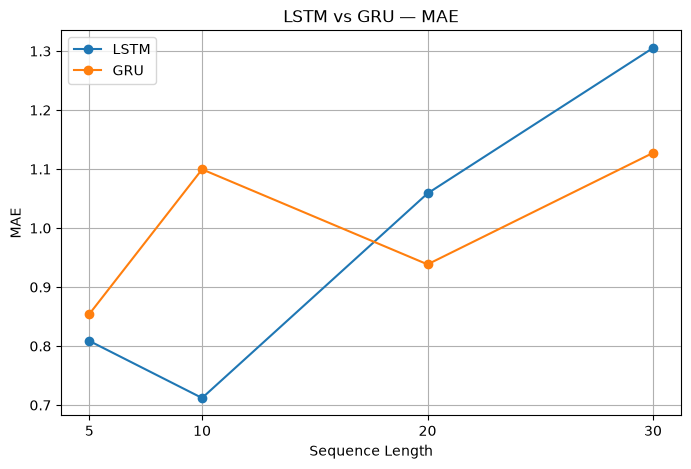

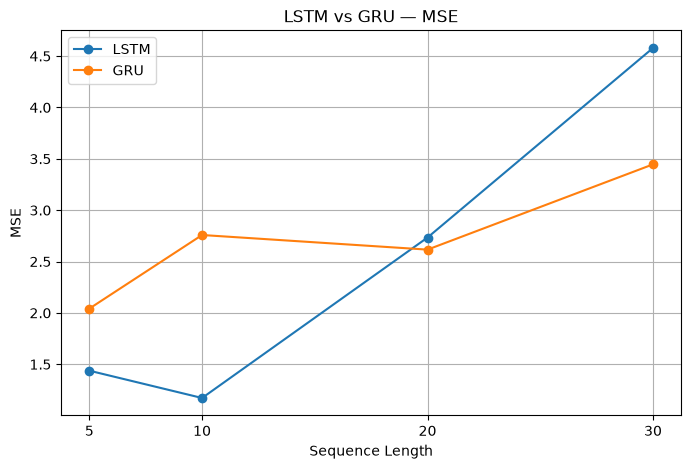

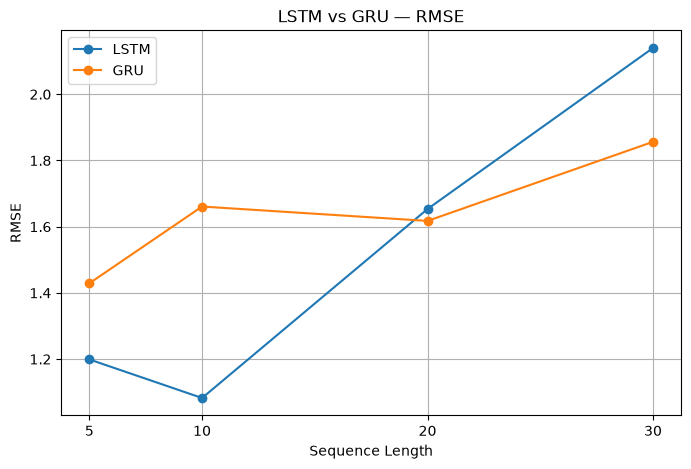

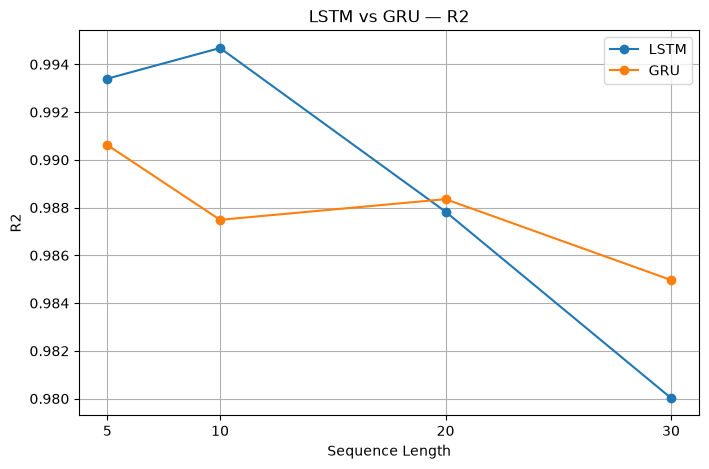

In [71]:
import matplotlib.pyplot as plt

metrics = ["MAE", "MSE", "RMSE", "R2"]

for metric in metrics:
    plt.figure(figsize=(8, 5))

    lstm_data = comparison_df[
        comparison_df["Model"] == "LSTM"
    ]

    gru_data = comparison_df[
        comparison_df["Model"] == "GRU"
    ]

    plt.plot(
        lstm_data["sequence_length"],
        lstm_data[metric],
        marker="o",
        label="LSTM"
    )

    plt.plot(
        gru_data["sequence_length"],
        gru_data[metric],
        marker="o",
        label="GRU"
    )

    plt.xlabel("Sequence Length")
    plt.ylabel(metric)
    plt.title(f"LSTM vs GRU — {metric}")
    plt.xticks([5, 10, 20, 30])
    plt.legend()
    plt.grid(True)

    plt.show()

In [72]:
comparison_df.to_csv(
    "../data/processed/lstm_vs_gru_comparison.csv",
    index=False
)

print("LSTM vs GRU comparison saved successfully.")
print(comparison_df)

LSTM vs GRU comparison saved successfully.
  Model  sequence_length       MAE       MSE      RMSE        R2
0  LSTM                5  0.808700  1.437600  1.199000  0.993400
1  LSTM               10  0.711984  1.171819  1.082506  0.994685
2  LSTM               20  1.058678  2.733736  1.653401  0.987829
3  LSTM               30  1.305166  4.578792  2.139811  0.980026
4   GRU                5  0.854308  2.041993  1.428983  0.990620
5   GRU               10  1.099531  2.758420  1.660849  0.987488
6   GRU               20  0.938461  2.616108  1.617439  0.988353
7   GRU               30  1.127343  3.446014  1.856344  0.984967


In [73]:
print("===== LSTM RESULTS =====")
display(lstm_results)

print("\n===== GRU RESULTS =====")
display(gru_results)

print("\n===== LSTM vs GRU COMPARISON =====")
display(comparison_df)

===== LSTM RESULTS =====


,sequence_length,MAE,MSE,RMSE,R2,Model
0,5,0.808700,1.437600,1.199000,0.993400,LSTM
1,10,0.711984,1.171819,1.082506,0.994685,LSTM
2,20,1.058678,2.733736,1.653401,0.987829,LSTM
3,30,1.305166,4.578792,2.139811,0.980026,LSTM



===== GRU RESULTS =====


,sequence_length,MAE,MSE,RMSE,R2,Model
0,5,0.854308,2.041993,1.428983,0.990620,GRU
1,10,1.099531,2.758420,1.660849,0.987488,GRU
2,20,0.938461,2.616108,1.617439,0.988353,GRU
3,30,1.127343,3.446014,1.856344,0.984967,GRU



===== LSTM vs GRU COMPARISON =====


,Model,sequence_length,MAE,MSE,RMSE,R2
0,LSTM,5,0.808700,1.437600,1.199000,0.993400
1,LSTM,10,0.711984,1.171819,1.082506,0.994685
2,LSTM,20,1.058678,2.733736,1.653401,0.987829
3,LSTM,30,1.305166,4.578792,2.139811,0.980026
4,GRU,5,0.854308,2.041993,1.428983,0.990620
5,GRU,10,1.099531,2.758420,1.660849,0.987488
6,GRU,20,0.938461,2.616108,1.617439,0.988353
7,GRU,30,1.127343,3.446014,1.856344,0.984967


## LSTM vs GRU Results

The sequence models were evaluated using sequence lengths of 5, 10, 20, and 30 while keeping the participant-session group-based train-test split.

### LSTM

For LSTM, sequence length 10 produced the lowest MAE (0.711984), MSE (1.171819), and RMSE (1.082506), along with the highest R² (0.994685) among the tested sequence lengths.

### GRU

For GRU, sequence length 5 produced the lowest MAE (0.854308), MSE (2.041993), and RMSE (1.428983), along with the highest R² (0.990620) among the tested sequence lengths.

### Sequence Length Observation

Increasing the sequence length did not consistently improve performance. The results indicate that the relationship between historical context and prediction performance depends on the recurrent architecture and sequence length.

### Important Limitation

The productivity score used as the target was constructed from the same six behavioral features that are supplied to the machine-learning models. Therefore, the high performance of the models demonstrates their ability to reproduce the constructed productivity score; it should not be interpreted as independent validation of real-world employee productivity.